# Text Analysis of Literary Works

Basic NLP workflow on a small corpus of books: preprocessing, frequency analysis, TF-IDF, similarity and PCA visualization.

In [ ]:
# Install dependencies
!pip install requests nltk stopwordsiso scikit-learn matplotlib

## 1. Downloading selected books

Downloading plain text books and storing them as a corpus.

In [ ]:
import requests

corpora = []

urls = ["https://wolnelektury.pl/media/book/txt/pan-tadeusz.txt",
        "https://wolnelektury.pl/media/book/txt/dziewczynka-z-zapalkami.txt",
        "https://wolnelektury.pl/media/book/txt/dickens-opowiesc-wigilijna.txt",
        "https://wolnelektury.pl/media/book/txt/cierpienia-mlodego-wertera.txt",
        "https://wolnelektury.pl/media/book/txt/nie-boska-komedia.txt",
        "https://wolnelektury.pl/media/book/txt/saint-exupery-maly-ksiaze.txt",
        "https://wolnelektury.pl/media/book/txt/konrad-wallenrod.txt"]

for url in urls:
  response = requests.get(url)
  text = response.text
  corpora.append(text)

print(len(corpora))

7


## 2. Text preprocessing

Cleaning and tokenizing text: lowercasing, removing stopwords and non-alphabetic tokens.

In [ ]:
import nltk
import stopwordsiso
from nltk.tokenize import word_tokenize
from stopwordsiso import stopwords

nltk.download('punkt')
nltk.download('punkt_tab')
stop_words = set(stopwords("pl"))

tokens_corpora = []
corpora_cleaned = []
i = 1

for i, book in enumerate(corpora, start=1):
  tokens = word_tokenize(book.lower())
  filtered_tokens = [word for word in tokens if word not in stop_words and word.isalpha()]
  tokens_corpora.append(filtered_tokens)

  cleaned_text = ' '.join(filtered_tokens)
  corpora_cleaned.append(cleaned_text)

  print(f"\nBook {i}")
  print(f"Token count: {len(filtered_tokens)}")
  print("First 10 tokens:", filtered_tokens[:10])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Book 1
Token count: 43643
First 10 tokens: ['adam', 'mickiewicz', 'tadeusz', 'ostatni', 'zajazd', 'litwie', 'isbn', 'księga', 'pierwsza', 'gospodarstwo']

Book 2
Token count: 657
First 10 tokens: ['hans', 'christian', 'andersen', 'dziewczynka', 'zapałkami', 'tłum', 'cecylia', 'niewiadomska', 'isbn', 'zimno']

Book 3
Token count: 15140
First 10 tokens: ['charles', 'dickens', 'opowieść', 'wigilijna', 'tłum', 'nieznany', 'isbn', 'opowieść', 'fantastyczna', 'duch']

Book 4
Token count: 19962
First 10 tokens: ['johann', 'wolfgang', 'von', 'goethe', 'cierpienia', 'młodego', 'wertera', 'tłum', 'franciszek', 'mirandola']

Book 5
Token count: 9827
First 10 tokens: ['zygmunt', 'krasiński', 'komedia', 'isbn', 'błędów', 'nagromadzonych', 'przodków', 'dodali', 'czego', 'znali']

Book 6
Token count: 6421
First 10 tokens: ['antoine', 'de', 'mały', 'książę', 'tłum', 'agata', 'kozak', 'isbn', 'leonowi', 'werthowi']

Book 7
Token count: 8123
First 10 tokens: ['adam', 'mickiewicz', 'konrad', 'wallenrod'

## 3. Word frequency analysis and Zipf's law

Most frequent words and their distribution across documents, then comparing word frequency with rank (~1/r relationship).


BOOK 1:
[('rzekł', 155), ('hrabia', 129), ('sędzia', 127), ('tadeusz', 106), ('wojski', 89), ('potem', 86), ('oczy', 78), ('domu', 76), ('szlachta', 64), ('cóż', 62), ('ręce', 60), ('gerwazy', 60), ('głowy', 56), ('telimena', 56), ('tadeusza', 54), ('razem', 54), ('panie', 54), ('głowę', 53), ('ziemi', 51), ('robak', 51)]



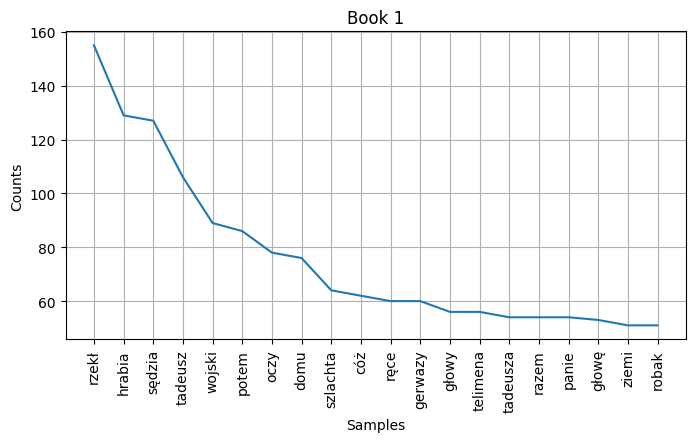

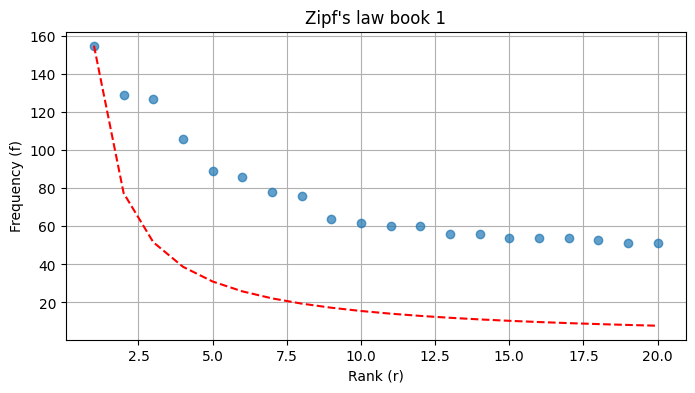


BOOK 2:
[('dziewczynka', 8), ('zapałka', 6), ('miała', 5), ('ręce', 5), ('lektury', 5), ('jedną', 4), ('nikt', 4), ('dziewczynki', 4), ('zapaliła', 4), ('wolne', 4), ('wolnych', 4), ('lektur', 4), ('chciała', 3), ('śniegu', 3), ('zapałek', 3), ('ciepłym', 3), ('jasne', 3), ('jasny', 3), ('zgasła', 3), ('gęś', 3)]



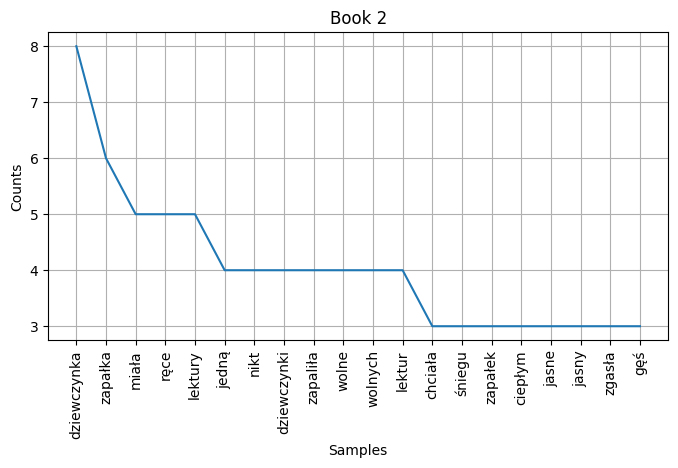

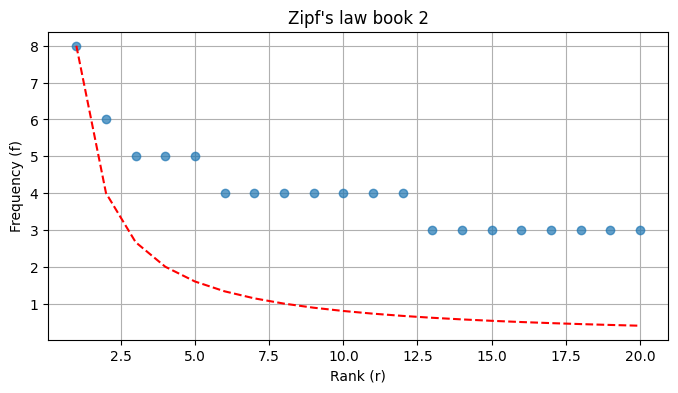


BOOK 3:
[('scrooge', 358), ('duch', 125), ('ducha', 46), ('chwili', 43), ('domu', 38), ('drzwi', 34), ('pokoju', 34), ('mógł', 34), ('bob', 34), ('zapytał', 33), ('zawołał', 32), ('rzekł', 31), ('chociaż', 30), ('siebie', 29), ('cratchit', 29), ('bożego', 27), ('narodzenia', 26), ('dzieci', 26), ('siostrzeniec', 26), ('wciąż', 26)]



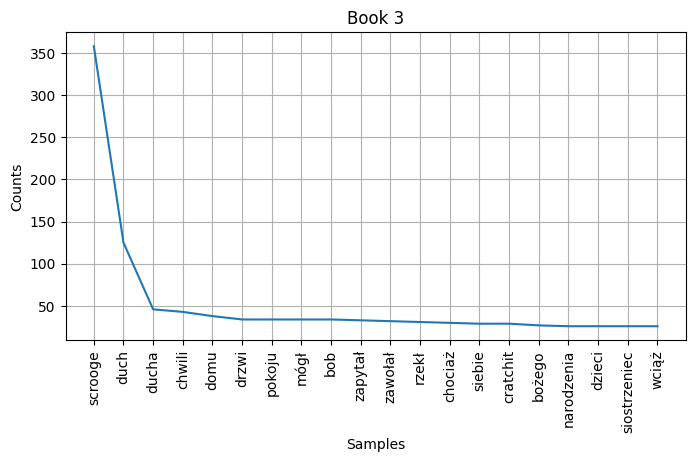

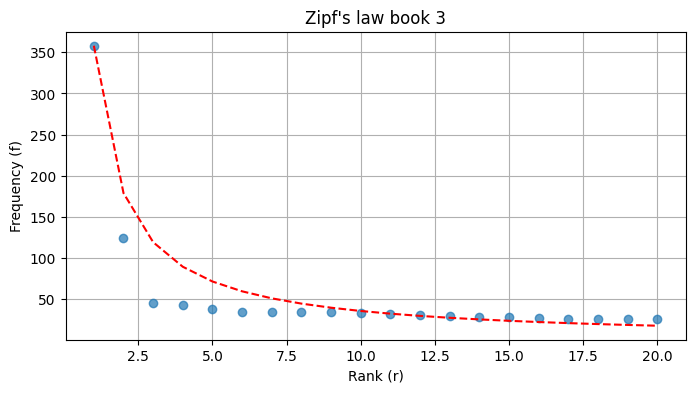


BOOK 4:
[('siebie', 59), ('potem', 56), ('drogi', 55), ('czyż', 49), ('lota', 49), ('jakże', 47), ('mogę', 46), ('przeto', 46), ('serce', 45), ('chwili', 45), ('loty', 44), ('albert', 44), ('człowieka', 42), ('dzieci', 38), ('jeno', 37), ('życia', 36), ('człowiek', 36), ('wówczas', 36), ('słowa', 36), ('werter', 34)]



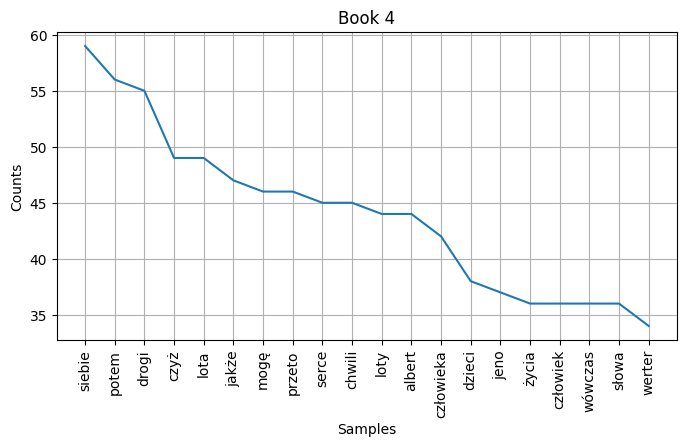

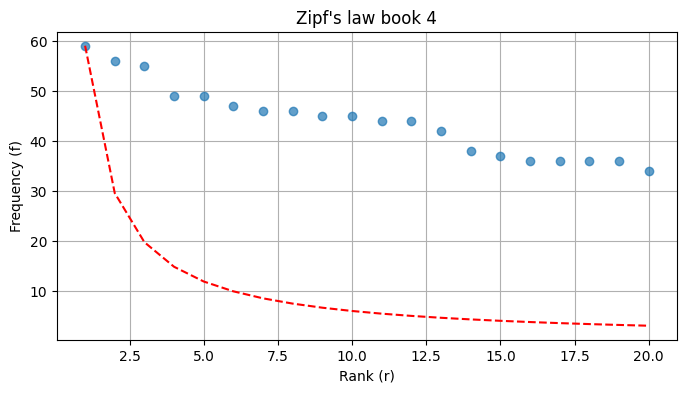


BOOK 5:
[('mąż', 259), ('pankracy', 77), ('leonard', 60), ('przechrzta', 51), ('żona', 49), ('głos', 49), ('orcio', 49), ('ojciec', 32), ('chór', 31), ('myśli', 28), ('panie', 26), ('boże', 25), ('ziemi', 23), ('głosy', 23), ('drugi', 22), ('twoich', 21), ('dziecię', 21), ('wolności', 21), ('lekarz', 20), ('ludzi', 19)]



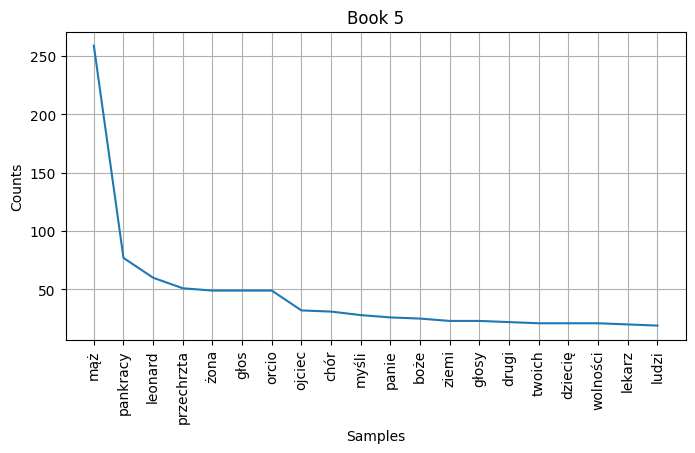

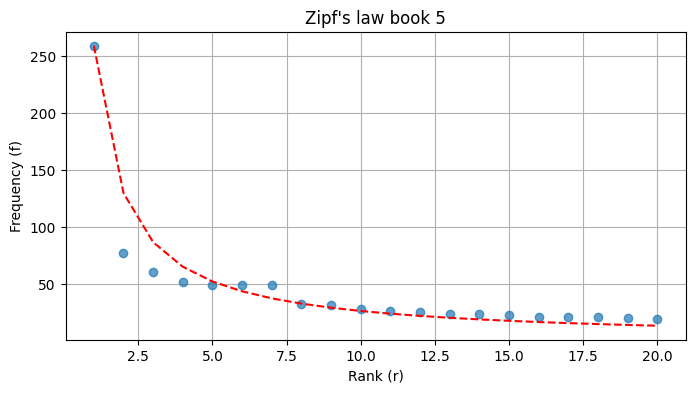


BOOK 6:
[('mały', 143), ('książę', 139), ('powiedział', 100), ('dzień', 29), ('gwiazdy', 28), ('małego', 26), ('księcia', 26), ('odpowiedział', 23), ('król', 23), ('dobry', 23), ('planecie', 22), ('będziesz', 21), ('lis', 21), ('odparł', 19), ('oczywiście', 18), ('trochę', 17), ('kwiat', 17), ('jesteś', 17), ('dorośli', 16), ('znaczy', 16)]



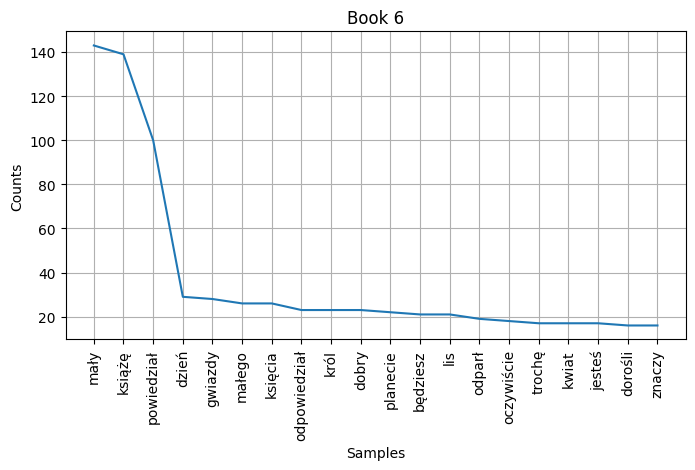

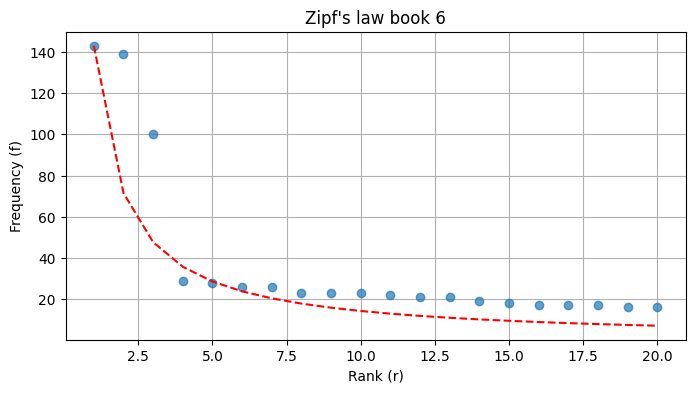


BOOK 7:
[('konrad', 30), ('wieży', 23), ('walter', 19), ('oczy', 18), ('dzień', 18), ('mię', 17), ('chcę', 17), ('dalej', 17), ('litwie', 16), ('pieśni', 16), ('długo', 16), ('niechaj', 16), ('dawniej', 15), ('śród', 15), ('litwy', 14), ('dotąd', 14), ('ziemi', 14), ('serce', 14), ('głos', 14), ('koniec', 14)]



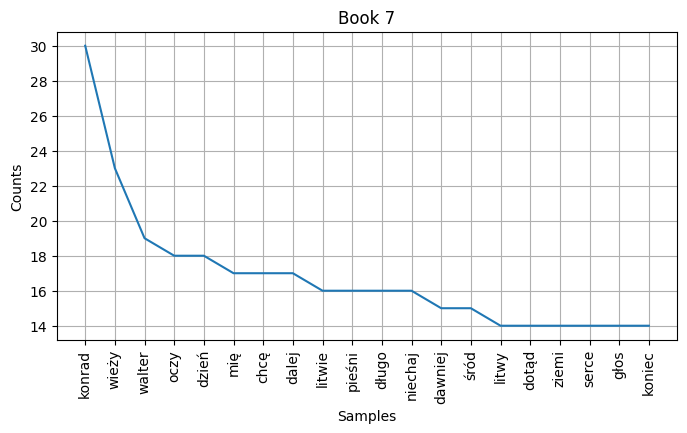

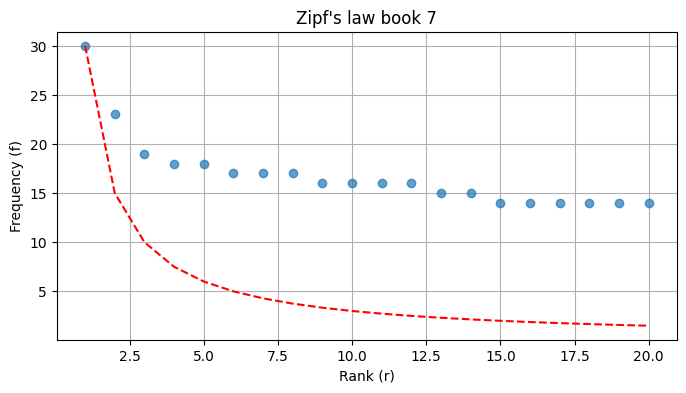

In [ ]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import numpy as np

for i, tokens in enumerate(tokens_corpora, start=1):
  counter = Counter(tokens)
  most_common = counter.most_common(20)
  print(f"\nBOOK {i}:\n{most_common}\n")


  samples = [word for word, count in most_common]
  counts = [count for word, count in most_common]
  plt.figure(figsize=(8,4))
  plt.plot(samples, counts)
  plt.title(f"Book {i}")
  plt.xticks(rotation=90)
  plt.xlabel("Samples")
  plt.ylabel("Counts")
  plt.grid()
  plt.show()

  frequencies = np.array([count for _, count in most_common])
  ranks = np.arange(1, len(frequencies) + 1)

  print("\n")
  plt.figure(figsize=(8,4))
  plt.plot(ranks, frequencies, marker='o', linestyle='none', alpha=0.7, label='data')
  plt.plot(ranks, frequencies[0] / ranks, linestyle='--', color='r', label='~1/r')
  plt.title(f"Zipf's law book {i}")
  plt.xlabel("Rank (r)")
  plt.ylabel("Frequency (f)")
  plt.grid()
  plt.show()

## 4. TF-IDF representation

Transforming documents into numerical vectors based on word importance.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(corpora_cleaned)

print(tfidf_matrix.shape)
print(vectorizer.get_feature_names_out())

(7, 33988)
['abel' 'abraham' 'abrahamie' ... 'żądło' 'żęciem' 'żłobem']


## 5. Document similarity

Cosine similarity between documents.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

titles = [
    "Pan Tadeusz",
    "Dziewczynka z zapałkami",
    "Opowieść wigilijna",
    "Cierpienia młodego Wertera",
    "Nie-Boska komedia",
    "Mały Książę",
    "Konrad Wallenrod"
]

similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(similarity_matrix, index=titles, columns=titles)

pd.set_option('display.expand_frame_repr', False)

print(similarity_df)


                            Pan Tadeusz  Dziewczynka z zapałkami  Opowieść wigilijna  Cierpienia młodego Wertera  Nie-Boska komedia  Mały Książę  Konrad Wallenrod
Pan Tadeusz                    1.000000                 0.073701            0.120908                    0.256296           0.152442     0.117417          0.281179
Dziewczynka z zapałkami        0.073701                 1.000000            0.045782                    0.071977           0.040206     0.035745          0.062339
Opowieść wigilijna             0.120908                 0.045782            1.000000                    0.146533           0.067974     0.079196          0.081789
Cierpienia młodego Wertera     0.256296                 0.071977            0.146533                    1.000000           0.161192     0.158637          0.215653
Nie-Boska komedia              0.152442                 0.040206            0.067974                    0.161192           1.000000     0.063015          0.137302
Mały Książę           

In [ ]:
import numpy as np

sim = similarity_df.copy()

np.fill_diagonal(sim.values, np.nan)

max_value = sim.max().max()
min_value = sim.min().min()

max_pair = sim.stack().idxmax()
min_pair = sim.stack().idxmin()

print(f"Max: {max_pair[0]}, {max_pair[1]}, {max_value:.3f}")
print(f"Min: {min_pair[0]}, {min_pair[1]}, {min_value:.3f}")


Max: Pan Tadeusz, Konrad Wallenrod, 0.281
Min: Dziewczynka z zapałkami, Mały Książę, 0.036


*Pan Tadeusz* and *Konrad Wallenrod* are the most similar, while *Mały Książę* and *Dziewczynka z zapałkami* are the least similar.

## 6. PCA visualization

2D projection of document vectors.

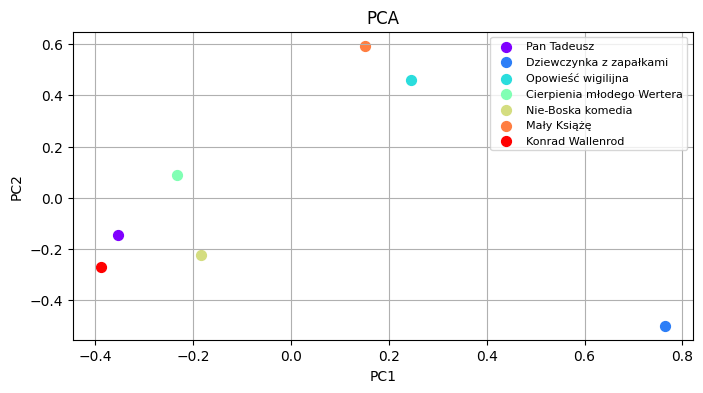

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

titles = [
    "Pan Tadeusz",
    "Dziewczynka z zapałkami",
    "Opowieść wigilijna",
    "Cierpienia młodego Wertera",
    "Nie-Boska komedia",
    "Mały Książę",
    "Konrad Wallenrod"
]

pca = PCA(n_components=2)

tfidf2 = pca.fit_transform(tfidf_matrix.toarray())

colors = plt.cm.rainbow(np.linspace(0, 1, len(corpora_cleaned)))

plt.figure(figsize=(8,4))
for i, title in enumerate(titles):
    plt.scatter(tfidf2[i, 0], tfidf2[i, 1],
                color=colors[i],
                s=50,
                label=title)

plt.title("PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.legend(loc="upper right", fontsize=8, frameon=True)
plt.show()

## Conclusion

The analysis shows that TF-IDF combined with cosine similarity is effective for comparing literary texts.  
Documents with similar style and vocabulary (e.g. *Pan Tadeusz* and *Konrad Wallenrod*) appear closer both in the similarity matrix and PCA space.  
